In [18]:
import pandas as pd
from datetime import datetime as dt, timedelta
import matplotlib.pyplot as plt
import seaborn as sns

# RFM avec Pandas

In [23]:
data_type = {
    "CustomerID": str
}
df = pd.read_csv("./data/RFM Dataset/online_retail.csv", dtype=data_type, parse_dates=["InvoiceDate"])
df.dropna(subset=['CustomerID'], inplace=True)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [24]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID             object
Country                object
dtype: object

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  object        
 7   Country      406829 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 27.9+ MB


In [26]:
df["Revenu"] = df.Quantity * df.UnitPrice
df.sample(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenu
323054,565239,23079,TOADSTOOL BEDSIDE LIGHT,6,2011-09-02 09:51:00,8.95,12670.0,France,53.70
203988,554617,85099B,JUMBO BAG RED RETROSPOT,1,2011-05-25 11:21:00,2.08,14593.0,United Kingdom,2.08
296214,562878,22230,JIGSAW TREE WITH WATERING CAN,1,2011-08-10 10:45:00,0.29,16241.0,United Kingdom,0.29
289598,562274,23206,LUNCH BAG APPLE DESIGN,10,2011-08-04 10:00:00,1.65,12704.0,Finland,16.50
280905,561511,22266,EASTER DECORATION HANGING BUNNY,64,2011-07-27 15:02:00,0.19,15624.0,United Kingdom,12.16


In [27]:
reference_date = df["InvoiceDate"].max()+timedelta(days = 15)

In [30]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate":lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "count",
    "Revenu": "sum"
})

In [32]:
rfm.rename(columns={
    "InvoiceDate":"Recency",
    "InvoiceNo": "Frequency",
    "Revenu": "Monetary"
}, inplace=True)

rfm.sample(5)

,Recency,Frequency,Monetary
CustomerID,,,
17660.0,155,45,196.00
12573.0,241,28,160.54
13748.0,110,28,948.25
13294.0,204,54,873.74
12521.0,157,38,599.68


In [33]:
r = pd.qcut(rfm["Recency"], q= 5,labels=range(5,0,-1))
f = pd.qcut(rfm["Frequency"], q= 5,labels=range(1,6))
m = pd.qcut(rfm["Monetary"], q= 5,labels=range(1,6))

rfm = rfm.assign(R = r.values, F = f.values, M = m.values)
rfm.sample(5)

,Recency,Frequency,Monetary,R,F,M
CustomerID,,,,,,
16947.0,250,21,406.48,1,2,2
12921.0,18,741,16389.74,5,5,5
16826.0,65,22,341.70,3,2,2
16320.0,186,56,1038.46,2,3,4
14162.0,188,25,289.36,2,2,2


In [34]:
rfm["RFM_Segment"] = rfm["R"].astype(str)+rfm["F"].astype(str)+rfm["M"].astype(str)
rfm["RFM_Score"] = rfm[["R","F","M"]].sum(axis=1)

rfm.sample(5)

,Recency,Frequency,Monetary,R,F,M,RFM_Segment,RFM_Score
CustomerID,,,,,,,,
17503.0,17,38,558.96,5,3,3,533,11
15201.0,93,97,927.84,2,4,4,244,10
17472.0,205,181,710.29,1,5,3,153,9
15594.0,30,104,1767.53,4,4,4,444,12
14937.0,71,35,1617.63,3,3,4,334,10


In [35]:
def Assign_RFM_Segment(score):
    if score<5:
        return "Low-value"
    elif score<9:
        return "Mid-value"
    else :
        return "High-value"
    
rfm["RFM_Segment_label"]=rfm["RFM_Score"].apply(Assign_RFM_Segment)

rfm.head()

,Recency,Frequency,Monetary,R,F,M,RFM_Segment,RFM_Score,RFM_Segment_label
CustomerID,,,,,,,,,
12346.0,340,2,0.00,1,1,1,111,3,Low-value
12347.0,16,182,4310.00,5,5,5,555,15,High-value
12348.0,89,31,1797.24,2,3,4,234,9,High-value
12349.0,33,73,1757.55,4,4,4,444,12,High-value
12350.0,324,17,334.40,1,2,2,122,5,Mid-value


In [48]:
RFM_Segment_count = rfm["RFM_Segment_label"].value_counts()
RFM_Segment_count

RFM_Segment_label
High-value    2337
Mid-value     1492
Low-value      543
Name: count, dtype: int64

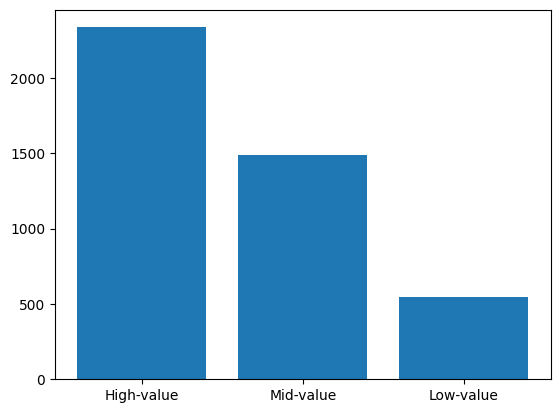

In [ ]:
plt.bar(RFM_Segment_count.index, RFM_Segment_count.values)
plt.show()

# RFM avec Scikit-lean (Machine learnig : apprentissage non supervisé)

In [55]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [57]:
rfm_cluster = rfm[['Recency','Frequency',"Monetary"]]
rfm_cluster

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,340,2,0.00
12347.0,16,182,4310.00
12348.0,89,31,1797.24
12349.0,33,73,1757.55
12350.0,324,17,334.40
...,...,...,...
18280.0,292,10,180.60
18281.0,195,7,80.82
18282.0,22,13,176.60


In [58]:
scale = StandardScaler()
scale = scale.fit_transform(rfm_cluster)

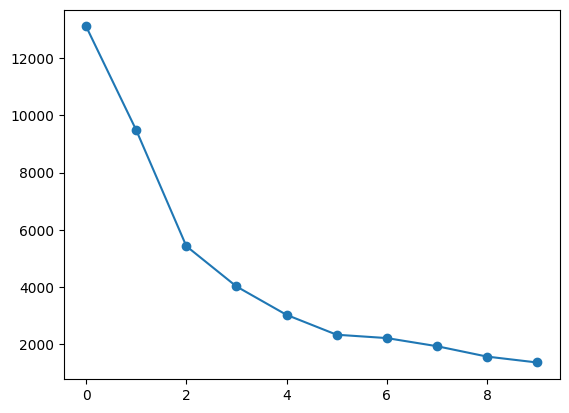

In [61]:
inertia = []

for i in range(1,11,1):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(scale)
    inertia.append(kmeans.inertia_)

plt.plot(inertia, marker="o")
plt.show()

In [66]:
kmean3 = KMeans(n_clusters=3)
kmean3.fit(scale)
rfm_cluster["Cluster"]=(kmean3.labels_+1)

rfm_cluster.sample(5)

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_20336\868964028.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm_cluster["Cluster"]=(kmean3.labels_+1)


,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
18252.0,65,98,526.67,1
15514.0,26,218,2963.19,1
13002.0,332,7,120.95,2
13304.0,365,21,300.42,2
16361.0,24,106,896.66,1


In [68]:
cluster = rfm_cluster.groupby("Cluster")[["Recency","Frequency","Monetary"]].mean()
cluster

,Recency,Frequency,Monetary
Cluster,,,
1,54.19344,104.924280,1951.687769
2,261.04827,27.704007,463.664873
3,19.00000,2845.583333,118713.023333


In [72]:
def Assign_RFM_Cluster(cluster):
    if cluster == 1:
        return "Mid-value"
    elif cluster == 2:
        return "Low-value"
    else :
        return "High-value"

In [73]:
rfm_cluster["RFM_Cluster_label"]= rfm_cluster["Cluster"].apply(Assign_RFM_Cluster)

rfm_cluster.sample(5)

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_20336\112826308.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm_cluster["RFM_Cluster_label"]= rfm_cluster["Cluster"].apply(Assign_RFM_Cluster)


,Recency,Frequency,Monetary,Cluster,RFM_Cluster_label
CustomerID,,,,,
17047.0,99,65,1100.90,1,Mid-value
15224.0,372,16,310.48,2,Low-value
14462.0,78,246,1965.90,1,Mid-value
13884.0,21,60,781.30,1,Mid-value
12970.0,21,151,452.24,1,Mid-value


In [78]:
Plot = rfm[["Recency","Frequency", "Monetary"]]
Plot.sample(5)

,Recency,Frequency,Monetary
CustomerID,,,
12849.0,45,51,1050.89
12873.0,296,4,374.00
13256.0,28,1,0.00
12462.0,16,72,1124.01
15988.0,33,27,158.03


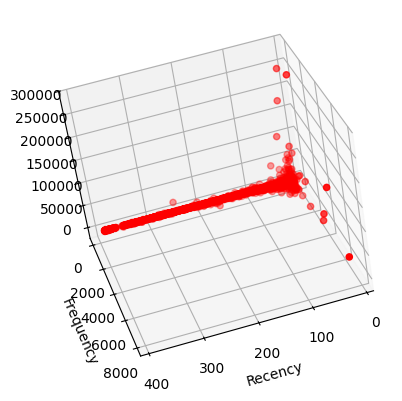

In [96]:
fig = plt.figure()
ax = fig.add_subplot(111, projection = "3d")

ax.scatter(rfm["Recency"],rfm["Frequency"], rfm["Monetary"], c="red")
ax.view_init(elev=30, azim=80, roll = 10 )

ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_label("Monetary")

plt.show()